# Polynomial Regression - Artificial Dataset

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
np.random.seed(42)
n = 1000

feat_1 = np.random.uniform(-3, 3, n)
feat_2 = np.random.uniform(-3, 3, n)
feat_3 = np.random.uniform(-3, 3, n)

# Non-linear target: quadratic + interaction + sine + noise
target = (
    2.0 * feat_1**2
    - 1.5 * feat_2**2
    + 2.5 * feat_1 * feat_3
    + 1.8 * np.sin(feat_2)
    + np.random.randn(n) * 0.3
)

df = pd.DataFrame({
    'feat_1': feat_1,
    'feat_2': feat_2,
    'feat_3': feat_3,
    'target': target
})

X = df[['feat_1', 'feat_2', 'feat_3']]
y = df['target']

X = df[['feat_1', 'feat_2', 'feat_3']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

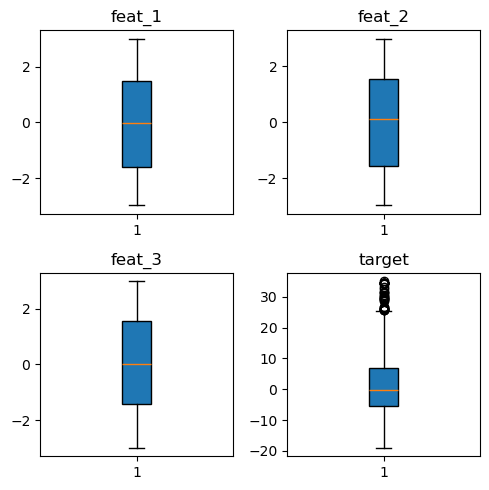

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(5, 5))

for ax, col in zip(axes.flatten(), df.columns):
    ax.boxplot(df[col], patch_artist=True)
    ax.set_title(col)

plt.tight_layout()
plt.show()

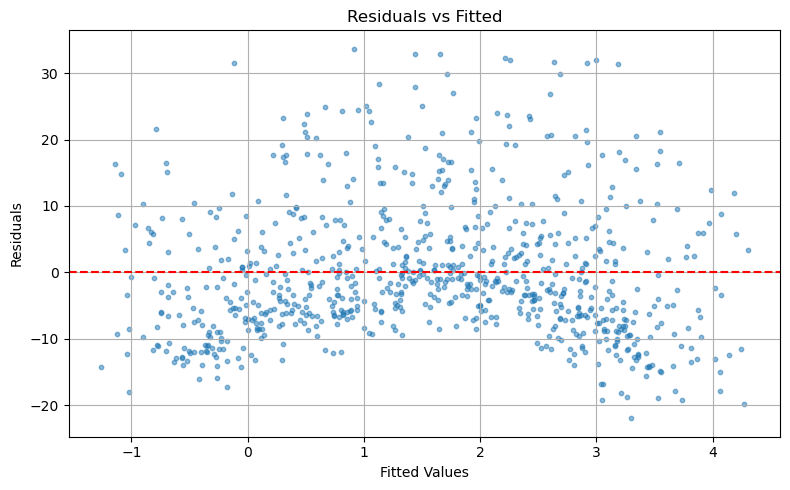

In [37]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
residuals = y_train - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.grid(True)
plt.tight_layout()
plt.show()

Realação não linear entre colunas, modelo é enviesado caso não se introduzam termos polinomiais

## Training

In [38]:
param_grid = [
    {
        "poly__degree": [1, 2, 3, 4, 5],
        "model": [LinearRegression()],
        "model__fit_intercept": [True, False],
    },
    {
        "poly__degree": [1, 2, 3, 4, 5],
        "model": [Ridge()],
        "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
        "model__fit_intercept": [True, False],
        "model__solver": ["auto", "svd", "cholesky", "lsqr"],
    },
    {
        "poly__degree": [1, 2, 3, 4, 5],
        "model": [Lasso(max_iter=10000)],
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
        "model__fit_intercept": [True, False],
        "model__selection": ["cyclic", "random"],
    },
    {
        "poly__degree": [1, 2, 3, 4, 5],
        "model": [ElasticNet(max_iter=10000)],
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
        "model__l1_ratio": [0.2, 0.5, 0.8],
        "model__fit_intercept": [True, False],
        "model__selection": ["cyclic", "random"],
    },
]

In [39]:
pipe = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('std', StandardScaler()),
    ('model', LinearRegression())
])

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', return_train_score=True, n_jobs=-1)
grid.fit(X_train, y_train)


,estimator,Pipeline(step...egression())])
,param_grid,"[{'model': [LinearRegression()], 'model__fit_intercept': [True, False], 'poly__degree': [1, 2, ...]}, {'model': [Ridge()], 'model__alpha': [0.01, 0.1, ...], 'model__fit_intercept': [True, False], 'model__solver': ['auto', 'svd', ...], ...}, ...]"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,degree,5


In [40]:
print(f'Best params: {grid.best_params_}')
print(f'Best CV R²:  {grid.best_score_:.4f}')

Best params: {'model': Lasso(max_iter=10000), 'model__alpha': 0.001, 'model__fit_intercept': True, 'model__selection': 'cyclic', 'poly__degree': 5}
Best CV R²:  0.9991


## Final model

In [41]:
final_model = grid.best_estimator_

final_model.fit(X_train, y_train)

,steps,"[('poly', ...), ('std', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,5
,interaction_only,False
,include_bias,False
,order,'C'
,copy,True
,with_mean,True
,with_std,True


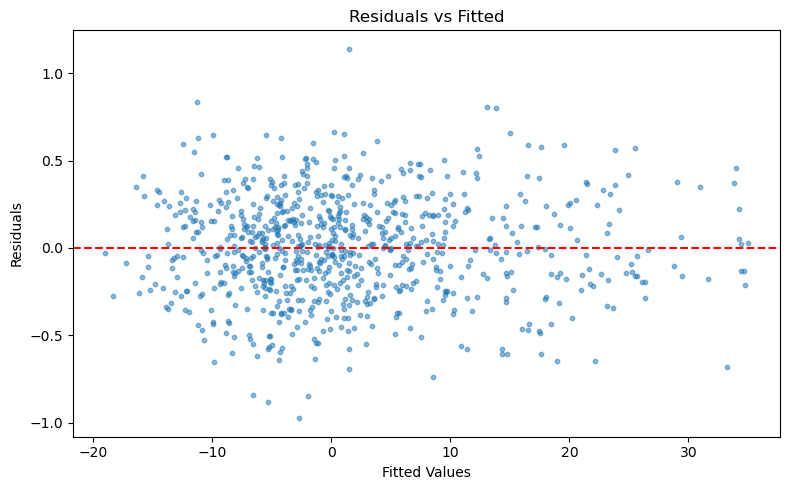

In [42]:
y_pred = final_model.predict(X_train)
residuals = y_train - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.tight_layout()
plt.show()

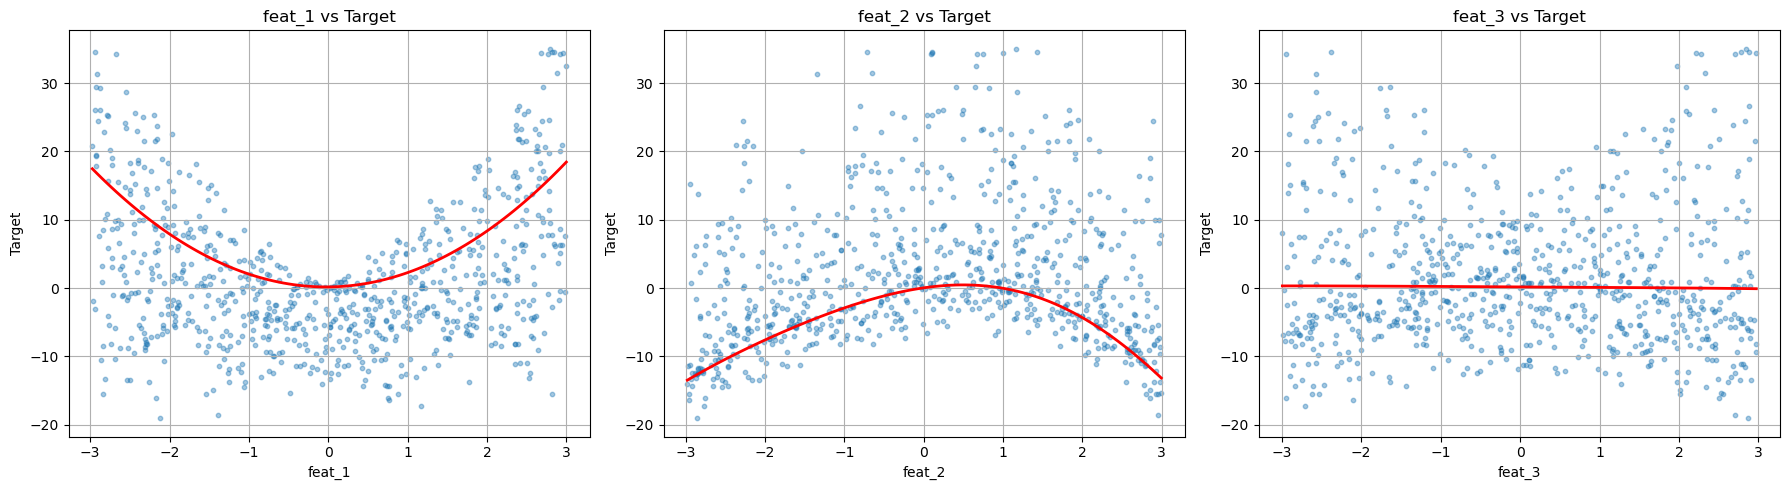

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
feature_names = ['feat_1', 'feat_2', 'feat_3']
X_mean = X_train.mean().values

for ax, feat_idx, feat_name in zip(axes, range(3), feature_names):
    # Scatter: feature vs target
    ax.scatter(X_train.iloc[:, feat_idx], y_train, alpha=0.4, s=10)

    # Regression line: vary one feature, keep others at mean
    x_range = np.linspace(X_train.iloc[:, feat_idx].min(), X_train.iloc[:, feat_idx].max(), 100)
    X_grid = pd.DataFrame(np.tile(X_mean, (100, 1)), columns=X_train.columns)
    X_grid.iloc[:, feat_idx] = x_range

    y_grid = final_model.predict(X_grid)
    ax.plot(x_range, y_grid, color='red', linewidth=2)

    ax.set_xlabel(feat_name)
    ax.set_ylabel('Target')
    ax.set_title(f'{feat_name} vs Target')
    ax.grid(True)

plt.tight_layout()
plt.show()

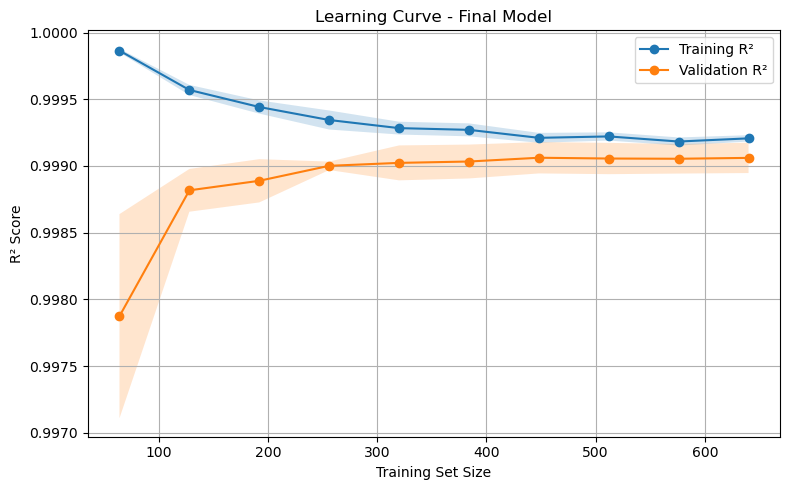

In [44]:
train_sizes, train_scores, val_scores = learning_curve(
    final_model, X_train, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training R²')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(train_sizes, val_mean, 'o-', label='Validation R²')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Learning Curve - Final Model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

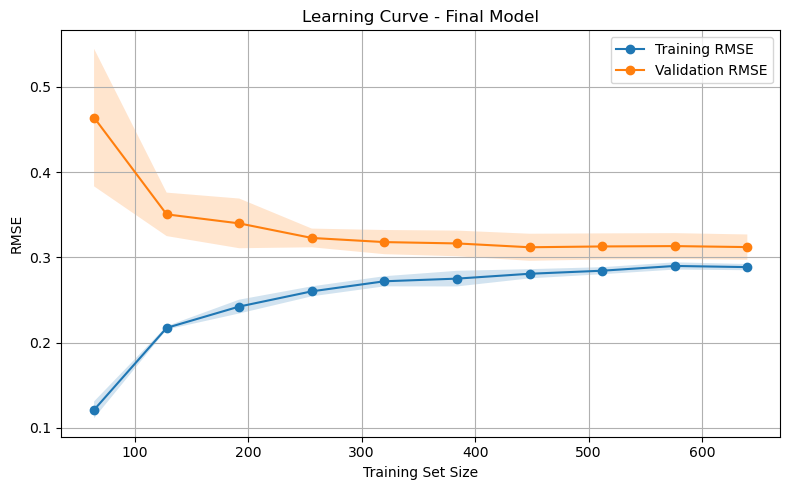

In [45]:
train_sizes, train_scores, val_scores = learning_curve(
    final_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = -train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = -val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_mean, "o-", label="Training RMSE")
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(train_sizes, val_mean, "o-", label="Validation RMSE")
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("Learning Curve - Final Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()